# Logistics Auditor

This is an AmaliTech project challenge. You can find more information here on [github](https://github.com/Molo-M/Logistics-Auditor-AmaliTech-Challenge)

## Table of Contents

1. [Story 1: The Schema Builder](#story-1-the-schema-builder)
2. [Story 2: The "Real" Delay Calculator](#story-2-the-"real"-delay-calculator)
3. [Story 3: The Geographic Heatmap](#story-3-the-geographic-heatmap).
4. [Story 4: The Sentiment Correlation](#story-4-the-sentiment-correlation)
5. [Bonus User Story: The "Translation" Challenge](#5.-bonus-user-story-the-"translation"-challenge)
6. [The "Candidate's Choice" Challenge](#6.-the-"candidate's-choice"-challenge)

**Import important libraries**

In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap

## Story 1: The Schema Builder

**As a** Data Engineer,
**I want** to join the Orders, Reviews, and Customers tables into a single master dataset,
**So that** I can analyze a customer's location and their review score in the same row.

- **Acceptance Criteria:**
  - Load the raw CSVs into your notebook.
  - Perform the correct joins (e.g., join Reviews to Orders on `order_id`, join Customers to Orders on `customer_id`).
  - **Check:** Ensure you don't accidentally duplicate rows (a common error with 1-to-many joins).

#### a) Load the raw CSVs into the notebook

In [2]:
olist_customers_dataset = pd.read_csv("olist_customers_dataset.csv")
olist_orders_dataset = pd.read_csv("olist_orders_dataset.csv")
olist_order_reviews_dataset = pd.read_csv("olist_order_reviews_dataset.csv")
olist_products_dataset = pd.read_csv("olist_products_dataset.csv")
olist_geolocation_dataset = pd.read_csv("olist_geolocation_dataset.csv")
product_category_name_translation = pd.read_csv("product_category_name_translation.csv")

#### b) Perform the correct joins in order to create master dataset

Join the customers and orders datasets

In [3]:
customers_orders = pd.merge(olist_customers_dataset, olist_orders_dataset, on="customer_id", how="left")

Make sure that there are no duplicates:

In [4]:
print(customers_orders["order_id"].is_unique)
print(customers_orders["customer_id"].is_unique)
print(customers_orders["customer_unique_id"].is_unique)

True
True
False


**Note:** The *customer_unique_id* column has repeated values because there are cases where a customer ordered **more than once.**

Aggregate the order reviews table, because some orders have more than 1 review:

In [5]:
reviews_agg = (
    olist_order_reviews_dataset
    .groupby("order_id")
    .agg(
        review_score=("review_score", "mean"), # Find the mean (average) where one order has more than one review
        review_count=("review_id", "count") # Column showing whether an order had 1 review or more
    )
    .reset_index()
)

Join the new table with the aggregated reviews table.

In [6]:
cust_orders_revs = pd.merge(customers_orders, reviews_agg, on="order_id", how="left")

In [7]:
cust_orders_revs

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_count
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,4.0,1.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,5.0,1.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,5.0,1.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,5.0,1.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,5.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25 00:00:00,4.0,1.0
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20 00:00:00,5.0,1.0
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02 00:00:00,1.0,1.0
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05 00:00:00,5.0,1.0


Make sure that there are no duplicates

In [8]:
print(cust_orders_revs["order_id"].is_unique)

True


## Story 2: The "Real" Delay Calculator

**As a** Logistics Manager,
**I want** to know the difference between the "Estimated Delivery Date" and the "Actual Delivery Date,"
**So that** I can see how often we are lying to customers.

- **Acceptance Criteria:**
  - Create a new calculated column: `Days_Difference` = `order_estimated_delivery_date` - `order_delivered_customer_date`.
  - Classify orders into statuses: "On Time", "Late", and "Super Late" (> 5 days late).
  - Handle missing values: Some orders were never delivered (`order_status` = 'canceled' or 'unavailable'). These should be excluded or flagged separately.

Convert date columns to date type:

In [9]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

cust_orders_revs[date_columns] = (cust_orders_revs[date_columns].apply(pd.to_datetime))

Verify that they converted:

In [10]:
cust_orders_revs.dtypes

customer_id                                 str
customer_unique_id                          str
customer_zip_code_prefix                  int64
customer_city                               str
customer_state                              str
order_id                                    str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
review_score                            float64
review_count                            float64
dtype: object

#### a) Handle missing values: Some orders were never delivered (order_status = 'canceled' or 'unavailable'). These should be excluded or flagged separately.

In [11]:
cust_orders_revs["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

**Result:** Only 96478 orders were delivered successfully. The orders that were not delivered will be excluded

In [12]:
delivered_orders = cust_orders_revs[cust_orders_revs["order_status"] == "delivered"].copy()
delivered_orders

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_count
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,4.0,1.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,5.0,1.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,5.0,1.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,5.0,1.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,5.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,4.0,1.0
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,5.0,1.0
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,1.0,1.0
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,5.0,1.0


#### b) Create a new calculated column: `Days_Difference` = `order_estimated_delivery_date` - `order_delivered_customer_date`.

Delivery delay was calculated using the full delivery timestamps rather than stripping the time component, allowing the analysis to capture the actual elapsed delivery duration.

**For example:** Between `2018-06-13` - `2018-06-14 17:58:51` = `1 day, 17:58:51` but `.dt.days` will classify it as **2 days**

In [13]:
delivered_orders["Days_Difference"] = (delivered_orders["order_estimated_delivery_date"] - delivered_orders["order_delivered_customer_date"]).dt.days
delivered_orders

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_count,Days_Difference
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,4.0,1.0,10.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,5.0,1.0,7.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,5.0,1.0,-2.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,5.0,1.0,12.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,5.0,1.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,4.0,1.0,11.0
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,5.0,1.0,8.0
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,1.0,1.0,-8.0
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,5.0,1.0,18.0


#### c) Classify orders into statuses: "On Time", "Late", and "Super Late" (> 5 days late).

In [14]:
def classify_delivery(days):
    if days >= 0:
        return "On Time"
    elif days >= -5:
        return "Late"
    else:
        return "Super Late"

delivered_orders["delivery_status"] = (delivered_orders["Days_Difference"].apply(classify_delivery))

In [15]:
delivered_orders

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_count,Days_Difference,delivery_status
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,4.0,1.0,10.0,On Time
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,5.0,1.0,7.0,On Time
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,5.0,1.0,-2.0,Late
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,5.0,1.0,12.0,On Time
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,5.0,1.0,5.0,On Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,4.0,1.0,11.0,On Time
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,5.0,1.0,8.0,On Time
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,1.0,1.0,-8.0,Super Late
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,5.0,1.0,18.0,On Time


## Story 3: The Geographic Heatmap

**As a** Regional Director,
**I want** to see which specific States (`customer_state`) have the highest percentage of late deliveries,
**So that** I can focus my repair efforts on the worst regions.

- **Acceptance Criteria:**
  - Calculate the % of late orders per State.
  - Visualize this on a map or a bar chart.
  - **Insight:** Identify if "Remote" states (far from the distribution center) are disproportionately affected.

#### a) Calculate the % of late orders per State:

In [16]:
# create a boolean column
delivered_orders["is_late"] = delivered_orders["delivery_status"].isin(
    ["Late", "Super Late"]
)

# create new data frame for the states and the number of late orders
state_analysis = (
    delivered_orders
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "count"), # calculate total number of orders per state
        late_orders=("is_late", "sum") # calculate total number of late orders per state
    )
    .reset_index()
)

# calculate the late percentage
state_analysis["late_percentage"] = (
    state_analysis["late_orders"]
    / state_analysis["total_orders"]
    * 100
).round(1)

# sort the states by the late percentage
state_analysis = state_analysis.sort_values(
    "late_percentage",
    ascending=False
)

In [17]:
state_analysis

,customer_state,total_orders,late_orders,late_percentage
1,AL,397,95,23.9
9,MA,717,141,19.7
16,PI,476,76,16.0
5,CE,1279,196,15.3
24,SE,335,51,15.2
4,BA,3256,457,14.0
18,RJ,12350,1664,13.5
26,TO,274,35,12.8
13,PA,946,117,12.4
21,RR,41,5,12.2


#### b) Visualize this on a map or a bar chart.

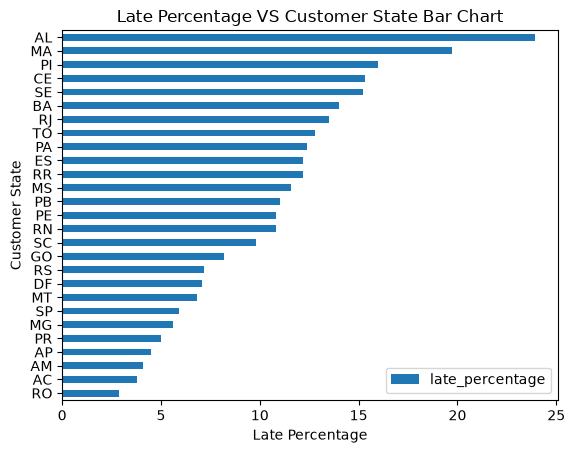

In [18]:
# Plotting using the 'customer_state' column as labels
state_analysis.sort_values("late_percentage").plot.barh(x='customer_state', y='late_percentage')
plt.title('Late Percentage VS Customer State Bar Chart')
plt.xlabel('Late Percentage')
plt.ylabel('Customer State')
plt.show()

#### c) **Insight:** Identify if "Remote" states (far from the distribution center) are disproportionately affected.

São Paulo was used as a geographic reference point to approximate remoteness (it is the economic center), since the dataset does not provide distribution-center coordinates.

Get a representative coordinate for every state, since each state in the `olist_geographical_dataset` has multiple zip codes:

In [19]:
state_coordinates = (olist_geolocation_dataset
    .groupby("geolocation_state")
    .agg(
        state_lat=("geolocation_lat", "mean"),
        state_lng=("geolocation_lng", "mean")
    )
    .reset_index()
)
state_coordinates.head(5)

,geolocation_state,state_lat,state_lng
0,AC,-9.702555,-68.451852
1,AL,-9.599729,-36.052017
2,AM,-3.349336,-60.537430
3,AP,0.086025,-51.234304
4,BA,-13.049361,-39.560649


Merge this locations dataframe to the main `cust_orders_revs` dataframe and export it to CSV file, for use in the Tableau Dashboard later:

In [20]:
master_dataset = cust_orders_revs.merge(
    state_coordinates,
    left_on="customer_state",
    right_on="geolocation_state",
    how="left"
)
master_dataset.to_csv('master_dataset.csv', index=False)

Merge the coordinates with the `state_analysis` dataframe:

In [21]:
state_analysis_geo = state_analysis.merge(
    state_coordinates,
    left_on="customer_state",
    right_on="geolocation_state",
    how="left"
)
state_analysis_geo.head(5)

,customer_state,total_orders,late_orders,late_percentage,geolocation_state,state_lat,state_lng
0,AL,397,95,23.9,AL,-9.599729,-36.052017
1,MA,717,141,19.7,MA,-3.798997,-44.818627
2,PI,476,76,16.0,PI,-5.754989,-42.509541
3,CE,1279,196,15.3,CE,-4.363151,-39.004140
4,SE,335,51,15.2,SE,-10.866199,-37.181169


Plot the geospatial heatmap:

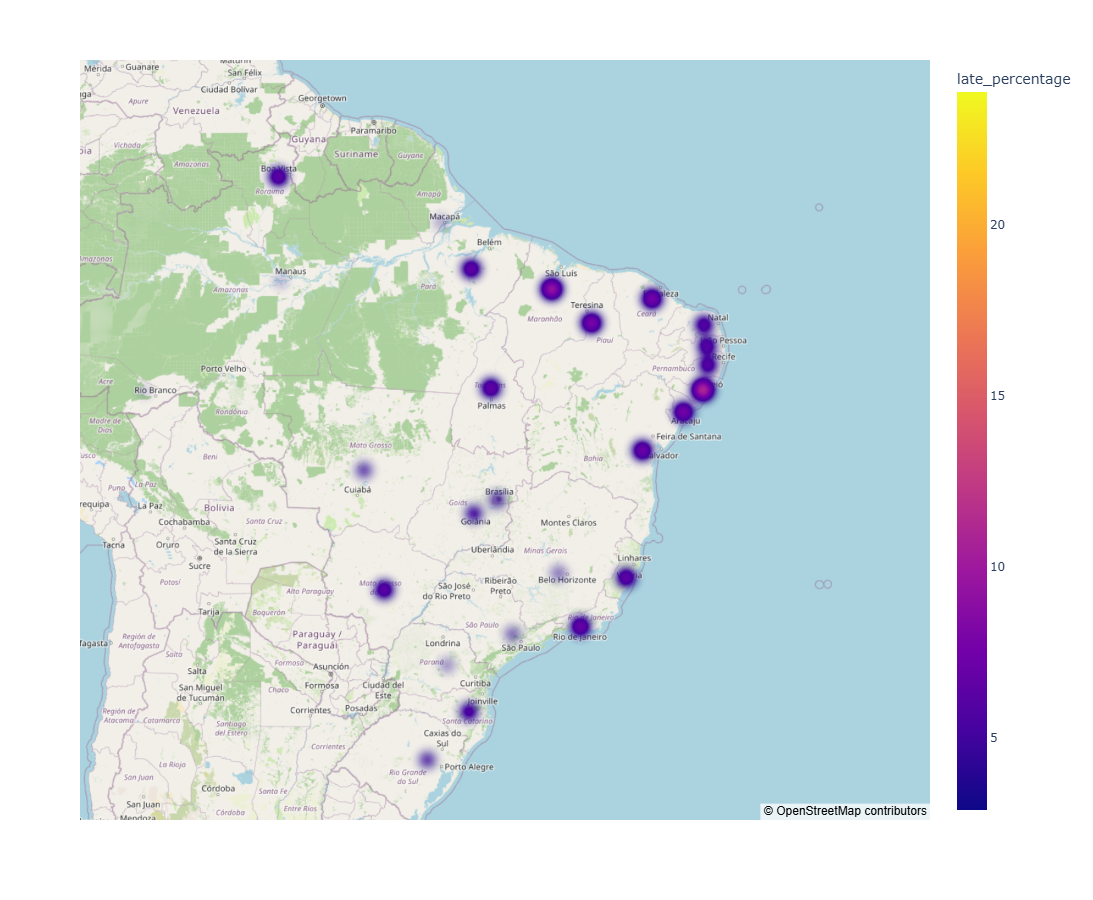

In [22]:
fig = px.density_map(
    state_analysis_geo,
    lat="state_lat",
    lon="state_lng",
    z="late_percentage",
    radius=20,
    center=dict(
        lat=state_analysis_geo.state_lat.mean(),
        lon=state_analysis_geo.state_lng.mean(),
    ),
    zoom=3.6,
    map_style="open-street-map",
    height=900,
)

fig.show()

**Insight:** It appears like states in **the far North** have been disproportionately affected.


## Story 4: The Sentiment Correlation

**As a** Customer Success Lead,
**I want** to see if late deliveries actually cause bad reviews,
**So that** I can prove to the CEO that logistics is the problem.

- **Acceptance Criteria:**
  - Create a visualization comparing "Delivery Delay (Days)" vs "Average Review Score (1-5)".
  - Show the average review score for "On Time" orders vs. "Late" orders.

---

#### a) Create a visualization comparing "Delivery Delay (Days)" vs "Average Review Score (1-5)".

In [23]:
# Create dataframe comparing delivery delay and average review score
status_review = (
    delivered_orders
    .groupby("delivery_status")["review_score"]
    .mean()
    .reset_index()
)

# Give more details to values in the delivery_status column
status_review['delivery_status'] = status_review['delivery_status'].replace({"Late": "Late (1-5 days)", "Super Late": "Super Late (More than 5 days)"})

status_review

,delivery_status,review_score
0,Late (1-5 days),3.461183
1,On Time,4.294292
2,Super Late (More than 5 days),1.791880


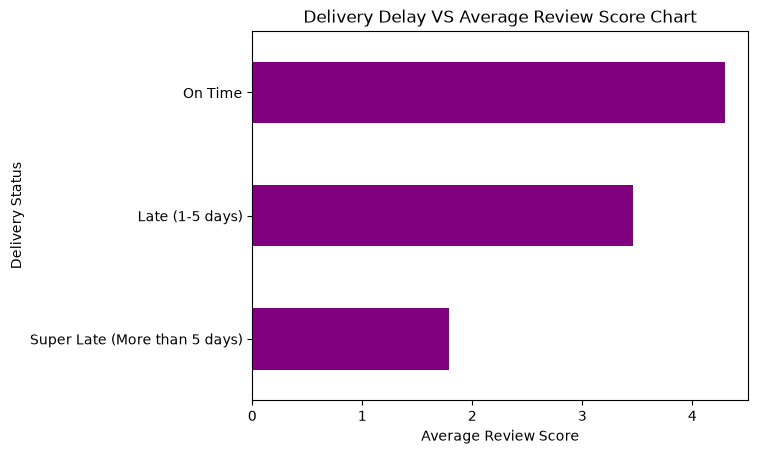

In [24]:
# Plotting a bar chart
status_review.sort_values("review_score").plot.barh(x='delivery_status', y='review_score', color="purple", legend=False)
plt.title('Delivery Delay VS Average Review Score Chart')
plt.xlabel('Average Review Score')
plt.ylabel('Delivery Status')
plt.show()

**Observation:** It is apparent that deliveries that were late for more than 5 days had the lowest average review score.

#### b) Show the average review score for "On Time" orders vs. "Late" orders.

* Since we have to compare "On Time" and "Late" orders, we are going to consider both `Late` and `Super Late` as **Late**.
* This means that we will be comparing the total "On Time" deliveries with the total late (Both Late and Super Late) deliveries.
* We will use the `is_late` binary column in our `delivered_orders` dataframe.

In [25]:
# Create dataframe comparing just "On Time" and "Late" orders
binary_delay_review = (
    delivered_orders
    .groupby("is_late")["review_score"]
    .mean()
    .reset_index()
)

# Change the Binary "True" and "False" to "On Time" and "Late" respectively
binary_delay_review['is_late'] = binary_delay_review['is_late'].replace({False: "On Time", True: "Late"})

binary_delay_review

,is_late,review_score
0,On Time,4.294292
1,Late,2.568523


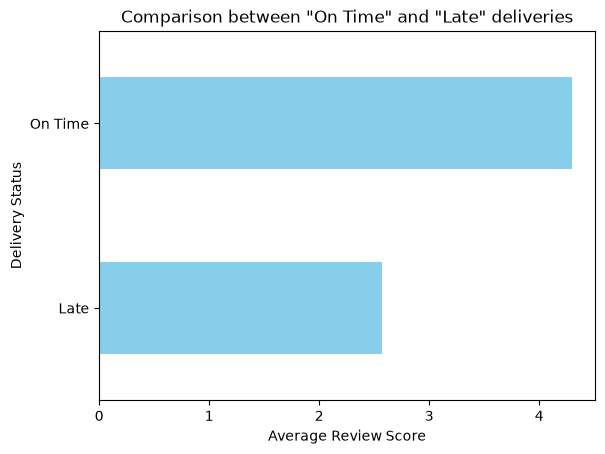

In [26]:
# Plotting a bar chart
binary_delay_review.sort_values("review_score").plot.barh(x='is_late', y='review_score', color="skyblue", legend=False)
plt.title('Comparison between "On Time" and "Late" deliveries')
plt.xlabel('Average Review Score')
plt.ylabel('Delivery Status')
plt.show()

## 5. Bonus User Story: The "Translation" Challenge

**As a** Global Analyst,
**I want** to see product categories in **English**, not Portuguese,
**So that** I can understand if "Furniture" is harder to ship than "Electronics".

- **Acceptance Criteria:**
  - The `product_category_name` is in Portuguese (e.g., `cama_mesa_banho`).
  - Use the `product_category_name_translation.csv` file included in the dataset (or create your own mapping) to translate these into English for your final dashboard.




In [27]:
# Merge the two dataframes with a "Left Join"
products = pd.merge(olist_products_dataset, product_category_name_translation, on="product_category_name", how="left")
products.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


## 6. The "Candidate's Choice" Challenge

**As a** Creative Problem Solver,
**I want** to include one extra feature or analysis that adds specific business value,
**So that** I can demonstrate my ability to think beyond the basic requirements.

- **Instructions:**
  - Add one more metric, chart, or drill-down.
  - **Requirement:** You must justify _why_ this feature matters to the business in your README.



* I added a pie chart that show the Order Status Distribution. 
* This additional metric shows the proportion of all orders that reached the delivered stage versus orders that were canceled, unavailable, or still in other stages of the fulfillment process. 
* This allows management to distinguish between problems occurring **before delivery** and problems occurring **during the final-mile delivery process.**

In [28]:
# Combine orders that were not delivered
delivery_status = cust_orders_revs.copy()
delivery_status.loc[delivery_status['order_status'] != "delivered", 'order_status'] = 'not delivered'

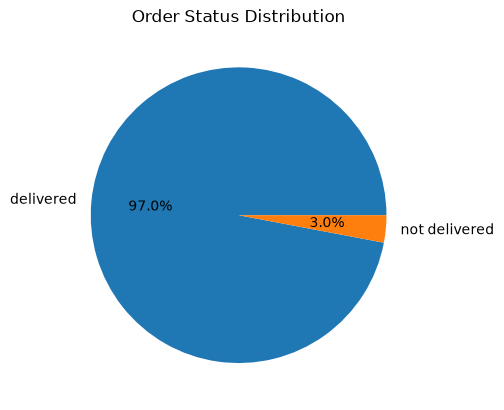

In [29]:
# Create a pie chart
delivery_status["order_status"].value_counts().plot.pie(
    autopct='%1.1f%%'  # Shows percentages on the slices
)

plt.title('Order Status Distribution')
plt.show()

**Observation:** 97% of orders reached delivered status, while approximately 3% remained in other statuses including canceled, unavailable, shipped, processing, invoiced, created, and approved.